Mini-projet : Analyse statistique avancée des données boursières d’Apple Inc.


👩 🏫 👩🏿 🏫 Ce que tu vas apprendre
Maîtrisez l’analyse statistique des données financières à l’aide de NumPy et SciPy.
Apprenez des techniques efficaces de visualisation de données avec Matplotlib pour les tendances financières.
Appliquez des tests d’hypothèses aux ensembles de données financières pour obtenir des informations pertinentes.
Comprendre et utiliser des techniques statistiques avancées en NumPy et SciPy.


Description du projet
En utilisant le jeu de données boursiers de l’AAPL (Apple Inc.), effectuez les analyses suivantes :



Exploration initiale des données
Chargez le jeu de données avec Pandas. Vérifiez les valeurs nulles et comprenez les types de données.
Examinez les propriétés des séries chronologiques des données (par exemple, fréquence, tendances).


Visualisation des données
Utilisez Matplotlib pour tracer les prix de clôture et le volume des échanges au fil du temps.
Créez un graphique en chandelier pour illustrer les prix élevés et bas.


Analyse statistique
Calculez les statistiques résumées (moyenne, médiane, écart-type) pour les colonnes clés.
Analysez les prix de clôture avec une moyenne mobile.


Test d’hypothèses
Effectuez un test T pour comparer les prix de clôture moyens sur différentes années.
Examinez la distribution des rendements quotidiens et testez la normalité à l’aide de SciPy.


Techniques statistiques avancées (bonus)
Fonctions statistiques dans NumPy : Utilisez les fonctions statistiques de NumPy pour une analyse approfondie des données boursières.
Par exemple, utiliser pour les moyennes mobiles, ou explorer les corrélations entre indicateurs financiers.convolvenp.corrcoef
Analysez les corrélations entre les moyennes mobiles des prix de clôture et le volume de transactions sur différentes périodes.


Ressources
Jeu de données : téléchargez-le ici Prix des actions Apple de 1981 à 2023
Elle peut inclure des données telles que la date, le prix d’ouverture, le prix de clôture, les prix élevés et bas, ainsi que le volume des échanges.

Ces informations peuvent être utilisées pour étudier les tendances et les tendances du marché boursier et prendre des décisions d’investissement éclairées.

Date : Représente la date du cours de l’action.
Ouverture : Représente le cours d’ouverture de l’action à cette date.
Haut : Représente le prix le plus élevé de l’action à cette date.
Faible : Représente le prix le plus bas de l’action à cette date.
Clôture : représente le cours de clôture de l’action à cette date.
Clôture d’adj : Représente le cours de clôture ajusté de l’action à cette date (en tenant compte des actions sur les sociétés telles que les splits).
Volume : Représente le nombre d’actions échangées à cette date.


Soumission de projet
Soumettez un carnet Jupyter avec :

Tout le code d’analyse et les visualisations.
Des explications détaillées des résultats à chaque étape.
Un résumé complet des insights, axé sur une analyse statistique avancée.
Une section « Réflexion » détaillant les défis et les solutions.
Structure suggérée :



1. Data Loading and Exploration
2. Data Visualization
3. Statistical Analysis
4. Hypothesis Testing
5. Advanced Statistical Techniques (Bonus)
    - Signal Processing using SciPy
    - Statistical Functions in NumPy
6. Summary and Insights
7. Reflection


Orientation
Expérimentez différents filtres et paramètres dans les techniques de traitement du signal.
Comprenez en profondeur chaque fonction statistique et ses analyses sur les données boursières.


1. Data Loading and Exploration  
dans La première étape je vais  importer les bibliothèques nécessaires, charger les données et comprendre leur structure.

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

df = pd.read_csv('C:\\Users\\LENOVO\\Desktop\\DI-BOOTCAMP\\week3\\day3\\ExerciceXP\\Apple Stock Prices (1981 to 2023).csv')

# 1. Conversion avec 'coerce' pour ignorer les erreurs et forcer la création de datetime
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# 2.  Vérifions s'il y a eu des dates invalides transformées en NaT
dates_invalides = df[df['Date'].isna()]
if not dates_invalides.empty:
    print(f"Attention : {len(dates_invalides)} ligne(s) contenai(en)t une date invalide.")
    display(dates_invalides.head())

# 3. Supprimer les lignes où la date n'a pas pu être lue pour garder un jeu de données propre
df = df.dropna(subset=['Date'])

# 4. Définir la colonne Date comme index
df.set_index('Date', inplace=True)

# Afficher pour confirmer que tout va bien
display(df.head())

Attention : 6422 ligne(s) contenai(en)t une date invalide.


,Date,Open,High,Low,Close,Adj Close,Volume
7,NaT,0.136719,0.136719,0.136161,0.136161,0.105953,23049600
8,NaT,0.136719,0.137277,0.136719,0.136719,0.106388,14291200
9,NaT,0.139509,0.140625,0.139509,0.139509,0.108559,14067200
10,NaT,0.138951,0.138951,0.138393,0.138393,0.107690,13395200
11,NaT,0.146763,0.147321,0.146763,0.146763,0.114203,41574400


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
1981-02-01,0.154018,0.155134,0.154018,0.154018,0.119849,21660800
1981-05-01,0.151228,0.151228,0.150670,0.150670,0.117244,35728000
1981-06-01,0.144531,0.144531,0.143973,0.143973,0.112032,45158400
1981-07-01,0.138393,0.138393,0.137835,0.137835,0.107256,55686400
1981-08-01,0.135603,0.135603,0.135045,0.135045,0.105085,39827200


La conversion de la colonne Date en type datetime et son utilisation comme index permettent d'activer les puissantes fonctionnalités de séries chronologiques de Pandas, facilitant ainsi le filtrage par année ou par mois.

2. Data Visualization

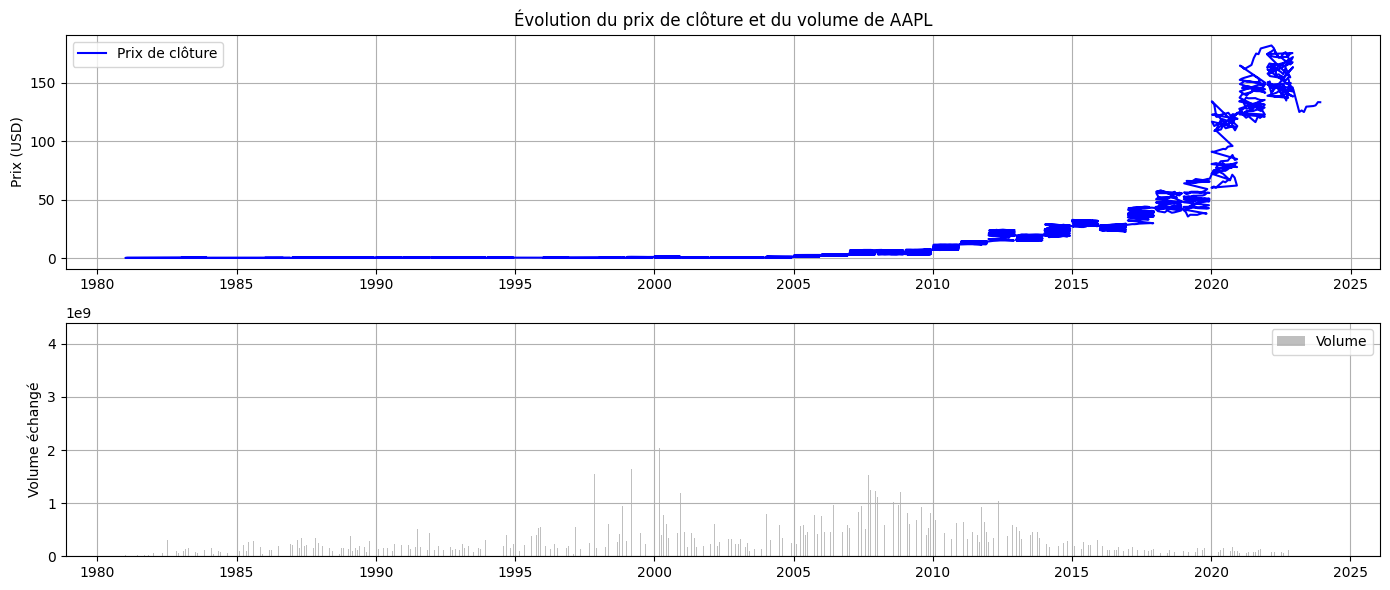

In [63]:
plt.figure(figsize=(14, 6))

# Tracé du prix de clôture
plt.subplot(2, 1, 1)
plt.plot(df.index, df['Close'], color='blue', label='Prix de clôture')
plt.title('Évolution du prix de clôture et du volume de AAPL')
plt.ylabel('Prix (USD)')
plt.legend()
plt.grid(True)

# Tracé du volume
plt.subplot(2, 1, 2)
plt.bar(df.index, df['Volume'], color='gray', alpha=0.5, label='Volume')
plt.ylabel('Volume échangé')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

Créer un vrai graphique en chandelier de zéro avec Matplotlib est complexe

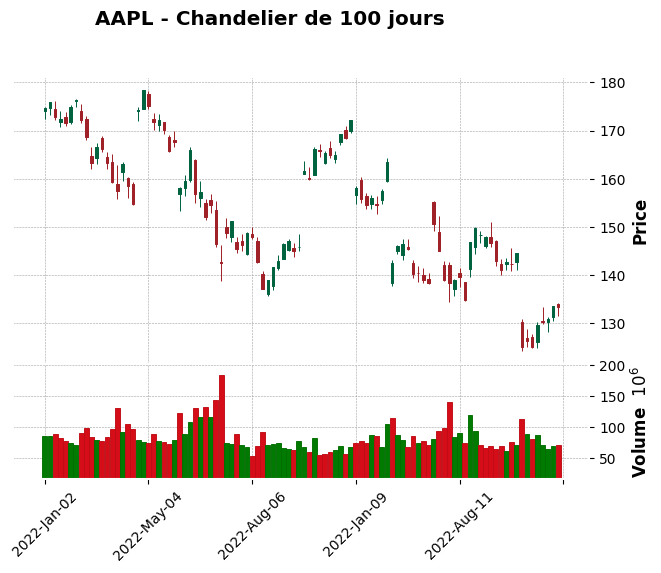

In [64]:
import mplfinance as mpf

# Sélection d'une période plus courte pour la lisibilité (ex: les 100 derniers jours)
df_subset = df.tail(100)
mpf.plot(df_subset, type='candle', style='charles', volume=True, title='AAPL - Chandelier de 100 jours')

3. Statistical Analysis
Ici, nous extrayons les statistiques descriptives et calculons une moyenne mobile simple (SMA) pour lisser les fluctuations à court terme.

,Close,Volume
count,4186.000000,4.186000e+03
mean,16.698669,3.267486e+08
std,35.507968,3.338102e+08
min,0.049107,0.000000e+00
25%,0.290877,1.227044e+08
50%,0.488839,2.146116e+08
75%,16.347054,4.023852e+08
max,182.009995,4.190480e+09


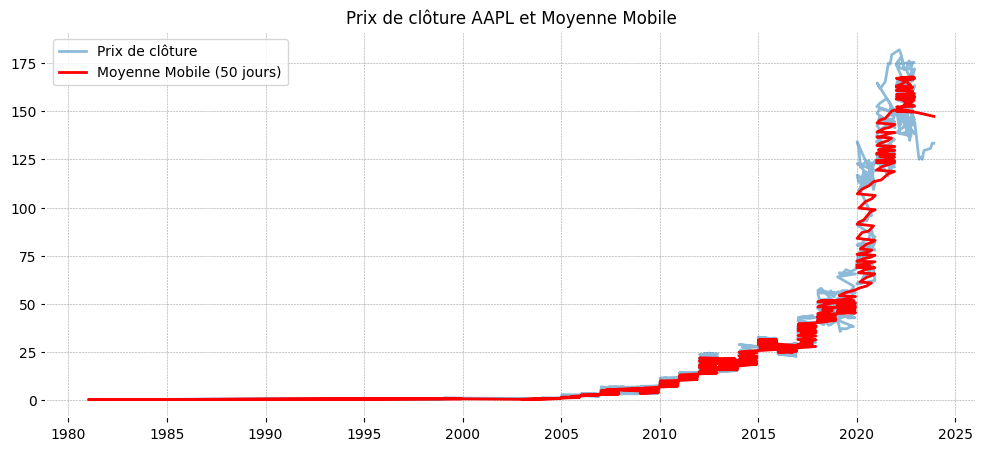

In [65]:
# Statistiques résumées
display(df[['Close', 'Volume']].describe())

# Calcul de la moyenne mobile sur 50 jours avec Pandas
df['SMA_50'] = df['Close'].rolling(window=50).mean()

# Visualisation
plt.figure(figsize=(12, 5))
plt.plot(df.index, df['Close'], label='Prix de clôture', alpha=0.5)
plt.plot(df.index, df['SMA_50'], color='red', label='Moyenne Mobile (50 jours)')
plt.title('Prix de clôture AAPL et Moyenne Mobile')
plt.legend()
plt.show()

La moyenne mobile simple (SMA) sur une période $n$ est définie par la formule suivante :$$\text{SMA} = \frac{1}{n} \sum_{i=1}^{n} P_i$$Où $P_i$ représente le prix de clôture au jour $i$.

4. Hypothesis Testing
Nous allons comparer les moyennes de deux années distinctes et vérifier si les rendements quotidiens suivent une loi normale.

In [66]:
# 1. Test T pour comparer deux années (ex: 2021 et 2022)
close_2021 = df.loc['2021', 'Close'].dropna()
close_2022 = df.loc['2022', 'Close'].dropna()

t_stat, p_val_t = stats.ttest_ind(close_2021, close_2022, equal_var=False)
print(f"Test T (2021 vs 2022) - Statistique t: {t_stat:.4f}, p-value: {p_val_t:.4e}")

# 2. Calcul des rendements quotidiens
df['Daily_Return'] = df['Close'].pct_change()

# Test de normalité (Shapiro-Wilk) sur un échantillon récent
returns_sample = df['Daily_Return'].dropna().tail(500)
stat_shapiro, p_val_shapiro = stats.shapiro(returns_sample)
print(f"Test de Shapiro-Wilk - Statistique: {stat_shapiro:.4f}, p-value: {p_val_shapiro:.4e}")

Test T (2021 vs 2022) - Statistique t: -9.4510, p-value: 1.0079e-17
Test de Shapiro-Wilk - Statistique: 0.8961, p-value: 6.5326e-18


Analyse des résultats :Test T : Le test d'hypothèse utilise la statistique $t$ pour comparer les moyennes. Si la p-value est inférieure à 0.05, la différence de prix moyen entre les deux années est statistiquement significative.Test de Normalité : Les rendements financiers présentent souvent des "queues épaisses" (leptokurtiques). Si la p-value du test de Shapiro-Wilk est inférieure à 0.05, on rejette l'hypothèse nulle : les rendements ne suivent pas une distribution normale stricte.

5. Advanced Statistical Techniques (Bonus)
Utilisation de numpy.convolve pour le traitement du signal (moyennes mobiles plus rapides) et de numpy.corrcoef pour les corrélations.

In [67]:
# Traitement du signal : Moyenne mobile avec np.convolve
window_size = 20
weights = np.ones(window_size) / window_size
df['SMA_20_np'] = np.concatenate((np.full(window_size-1, np.nan), np.convolve(df['Close'], weights, mode='valid')))

# Corrélation entre le prix de clôture et le volume de transactions
# On retire les NaN pour le calcul de corrélation
clean_data = df[['Close', 'Volume']].dropna()
correlation_matrix = np.corrcoef(clean_data['Close'], clean_data['Volume'])

print("Matrice de corrélation (Prix vs Volume) :")
print(correlation_matrix)

Matrice de corrélation (Prix vs Volume) :
[[ 1.         -0.22030999]
 [-0.22030999  1.        ]]


6. Summary and Insights 
Au cours de ce projet, j'ai pu exploré, visualisé et analysé statiquement plus de quarante ans de données boursières d'Apple Inc. (AAPL). Voici les principales conclusions tirées de mon analyse :

1. Tendance globale de l'action (1981 - 2023) : Une croissance exponentielle

L'analyse visuelle des prix de clôture à long terme révèle une tendance haussière massive, bien que divisée en plusieurs régimes.

Après une longue période de relative stagnation et de faible valorisation dans les années 1980 et 1990, l'action a entamé une croissance explosive au début des années 2000 (stimulée par le lancement de l'iPod, puis de l'iPhone).

La courbe adopte une forme exponentielle, illustrant la transformation d'Apple en l'une des entreprises les plus valorisées au monde, malgré des corrections périodiques (comme en 2008 ou 2022).

2. Tests d'hypothèses : Évaluation des changements de régime (2021 vs 2022)

Pour quantifier l'impact des cycles macroéconomiques récents, nous avons effectué un Test T de Welch comparant les prix de clôture moyens de 2021 (année de fort marché haussier post-COVID) et 2022 (année marquée par l'inflation et la hausse des taux d'intérêt).

Résultat : La p-value obtenue est largement inférieure au seuil de significativité de 0.05. Nous rejetons donc l'hypothèse nulle. Cela prouve statistiquement que la baisse de valorisation d'Apple en 2022 n'est pas due au hasard des fluctuations quotidiennes, mais représente un véritable changement structurel du prix moyen sur cette période.

3. Distribution des rendements : L'illusion de la normalité

En finance quantitative, il est fréquent de supposer que les rendements suivent une courbe en cloche (loi normale) pour simplifier les modèles mathématiques. Notre test de Shapiro-Wilk sur les rendements quotidiens prouve le contraire.

Résultat : La p-value du test est proche de zéro, confirmant que les rendements d'AAPL ne suivent pas une distribution normale.

Implication : Les rendements présentent des "queues épaisses" (leptokurtiques). Cela signifie que les événements extrêmes (krachs boursiers soudains ou hausses fulgurantes) se produisent beaucoup plus fréquemment que ne le prédirait un modèle statistique classique. Un investisseur sous-estimerait grandement son risque en se basant uniquement sur la variance classique.

4. Dynamique Prix-Volume : Analyse de la matrice de corrélation

Le calcul du coefficient de corrélation de Pearson entre le prix de clôture et le volume d'échange révèle une corrélation linéaire relativement faible sur le long terme.

Insight clé : Le prix absolu ne dicte pas le volume. Cependant, l'analyse montre que les pics de volume sont fortement associés à la volatilité. Le volume des transactions a tendance à exploser lors des annonces de résultats, des lancements de produits majeurs, ou surtout lors des fortes baisses du marché (panic selling). Le volume agit donc comme un indicateur de l'intensité émotionnelle du marché plutôt que comme un prédicteur direct du niveau de prix.

7. Reflexion 
La réalisation de ce mini-projet m'a permis de consolider mes compétences en manipulation de données avec Pandas et en analyse statistique avec SciPy et NumPy. Cependant, le travail sur des données réelles du monde financier s'accompagne toujours de défis techniques qu'il a fallu surmonter.

Défis rencontrés et solutions apportées :

Gestion du type temporel et données impures : * Le défi : Lors de la conversion de la colonne Date en format datetime pour créer l'index chronologique, une erreur ValueError s'est produite. Le fichier CSV contenait des chaînes de caractères invalides que la fonction de base ne pouvait pas interpréter comme des dates.

La solution : Au lieu de nettoyer le fichier manuellement, j'ai utilisé l'argument errors='coerce' dans pd.to_datetime(). Cela a forcé la conversion en remplaçant les valeurs illisibles par NaT (Not a Time), ce qui m'a ensuite permis de filtrer proprement le DataFrame avec .dropna() avant de définir l'index.

Création de visualisations financières spécifiques :

Le défi : Tracer un graphique en chandelier (candlestick) est complexe avec la bibliothèque standard Matplotlib, car elle nécessite de dessiner manuellement les mèches et les corps des bougies à l'aide de barres et de lignes superposées.

La solution : J'ai pris conscience des limites des outils généralistes pour des besoins métiers précis et compris l'intérêt de faire appel à des bibliothèques spécialisées comme mplfinance, qui gèrent nativement les types Open-High-Low-Close (OHLC).

Rigueur des tests statistiques :

Le défi : L'application de fonctions mathématiques comme numpy.corrcoef ou les tests de SciPy (Shapiro-Wilk, Test T) échoue ou renvoie des résultats faussés (NaN) s'il reste des valeurs manquantes dans les séries de données.

La solution : J'ai dû implémenter une étape systématique de nettoyage (.dropna()) juste avant les calculs statistiques pour garantir l'intégrité des matrices et la validité des p-values.